In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu


Wilcoxon signed-rank test: W = 0.00, p = 0.0002
       model          mean             sd
0  cellpose2  1.389312e+06  379639.139100
1    default  1.210883e+06  300272.083188
Wilcoxon signed-rank test: W = 0.00, p = 0.0002


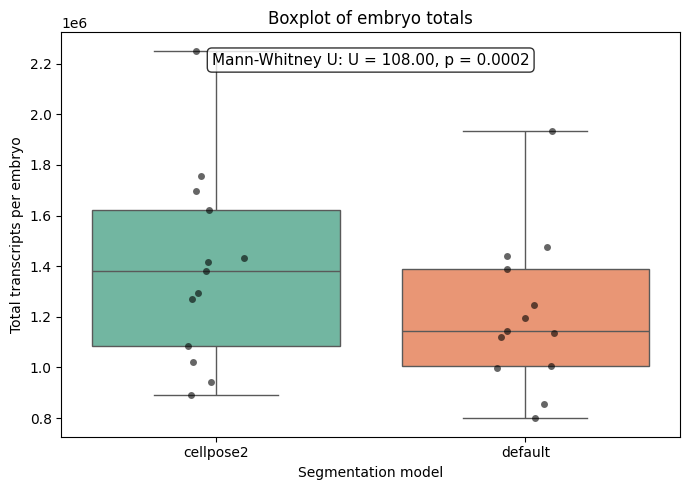

In [ ]:
######################### of chenxi 
import pandas as pd
from scipy.stats import wilcoxon

# Load combined data
combined = pd.read_csv('/Users/sdas/Downloads/Fig3c_data.csv')

# Extract embryo totals for each model
model1 = combined[combined['model'] == 'cellpose2'].sort_values('Custom cell groups')
model2 = combined[combined['model'] == 'default'].sort_values('Custom cell groups')

# Make sure the same embryos are being compared
assert model1['Custom cell groups'].values.tolist() == model2['Custom cell groups'].values.tolist()

# Paired values
cellpose2_totals = model1['embryo_total'].values
default_totals = model2['embryo_total'].values

# Wilcoxon signed-rank test
stat, p_value = wilcoxon(cellpose2_totals, default_totals)

print(f"Wilcoxon signed-rank test: W = {stat:.2f}, p = {p_value:.4f}")

# Summary statistics for bar plot
summary = combined.groupby('model')['embryo_total'].agg(
    mean='mean',
    sd='std'
).reset_index()

print(summary)

from scipy.stats import mannwhitneyu

cellpose2_totals = combined.loc[
    combined['model'] == 'cellpose2', 'embryo_total'
]

default_totals = combined.loc[
    combined['model'] == 'default', 'embryo_total'
]

u_stat, p_value = mannwhitneyu(
    cellpose2_totals,
    default_totals,
    alternative='two-sided'
)




from scipy.stats import wilcoxon

# Get paired measurements
cellpose2 = combined.loc[
    combined['model'] == 'cellpose2'
].sort_values('Custom cell groups')

default = combined.loc[
    combined['model'] == 'default'
].sort_values('Custom cell groups')

# Confirm that the embryo order is identical
assert (
    cellpose2['Custom cell groups'].values ==
    default['Custom cell groups'].values
).all()

# Wilcoxon signed-rank test
stat, p_value = wilcoxon(
    cellpose2['embryo_total'],
    default['embryo_total']
)

print(f"Wilcoxon signed-rank test: W = {stat:.2f}, p = {p_value:.4f}")

# -------------------------------
# 1. BOXPLOT with individual points
# -------------------------------
plt.figure(figsize=(7, 5))
ax1 = sns.boxplot(data=combined, x='model', y='embryo_total', hue='model',
                  palette='Set2', showfliers=False, legend=False)
sns.stripplot(data=combined, x='model', y='embryo_total',
              color='black', size=5, jitter=True, alpha=0.6, ax=ax1)

ax1.set_ylabel('Total transcripts per embryo')
ax1.set_xlabel('Segmentation model')
ax1.set_title('Boxplot of embryo totals')

# Add statistical annotation
stat_text = f"Mann-Whitney U: U = {u_stat:.2f}, p = {p_value:.4f}"
plt.text(0.5, 0.95, stat_text, transform=ax1.transAxes,
         fontsize=11, verticalalignment='top', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()


w_stat, w_p = wilcoxon(
    cellpose2['embryo_total'],
    default['embryo_total']
)

stat_text = f"Wilcoxon signed-rank test: W = {w_stat:.2f}, p = {w_p:.4f}"